# The Global AI Race: Who's Leading and Why? (2015-2026)
### Data Visualization Midterm - Part A: Programmatic Approach

**Dataset:** Global AI Index (2015-2026) - Readiness & Rankings  
**Source:** Kaggle  
**Countries:** 20 | **Years:** 2015-2026 | **Variables:** 27

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('viridis')

# Colorblind-safe palette
CB_PALETTE = ['#0077BB', '#33BBEE', '#009988', '#EE6677', '#CC3311',
              '#EE7733', '#BBBBBB', '#AA3377', '#66CCEE', '#228833']

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_csv('ai_index_main.csv')
print(f'Shape: {df.shape}')
print(f'Countries: {df["country"].nunique()}')
print(f'Years: {df["year"].min()} - {df["year"].max()}')
df.head()

Shape: (240, 27)
Countries: 20
Years: 2015 - 2026


,country,year,ai_adoption_consumer,ai_adoption_enterprise,internet_penetration,gdp_per_capita,education_index,tech_workforce_pct,cloud_infrastructure,data_availability,...,5g_coverage_pct,data_center_count,gpu_availability_index,ai_regulation_score,government_ai_spending,adoption_gap,ai_readiness_score,ai_index_score,ai_growth_rate,ai_global_rank
0,USA,2015,76.34,84.36,94.03,75328.19,0.95,8.59,86.10,92.36,...,100.0,263,84.16,80.28,150.38,8.02,85.16,84.60,0.000000,4.0
1,USA,2016,82.53,92.32,88.87,75183.82,0.95,18.37,87.59,85.02,...,100.0,641,97.28,85.61,144.04,9.79,85.09,88.16,0.042080,2.0
2,USA,2017,78.81,89.61,91.00,73139.66,0.95,16.44,86.75,87.40,...,100.0,612,94.75,86.33,47.78,10.80,84.07,86.74,-0.016107,3.0
3,USA,2018,85.00,92.17,98.00,70644.32,0.95,10.50,86.44,94.13,...,100.0,423,83.57,87.75,51.75,7.18,82.82,89.70,0.034125,3.0
4,USA,2019,84.46,95.81,92.76,71091.33,0.95,3.39,85.68,89.34,...,100.0,273,96.57,89.52,102.35,11.35,83.05,90.06,0.004013,2.0


---
## 2. Data Cleaning & Exploration (Data Mastery)

In [3]:
# Check data types
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')
print(f'\n=== Duplicates ===')
dupes = df.duplicated(subset=['country', 'year']).sum()
print(f'Duplicate country-year pairs: {dupes}')

=== Data Types ===
country                          str
year                           int64
ai_adoption_consumer         float64
ai_adoption_enterprise       float64
internet_penetration         float64
gdp_per_capita               float64
education_index              float64
tech_workforce_pct           float64
cloud_infrastructure         float64
data_availability            float64
ai_policy_score              float64
ai_startups_count              int64
ai_investment_billion_usd    float64
rd_spending_gdp_pct          float64
ai_research_papers             int64
stem_graduates_pct           float64
ai_talent_rank                 int64
5g_coverage_pct              float64
data_center_count              int64
gpu_availability_index       float64
ai_regulation_score          float64
government_ai_spending       float64
adoption_gap                 float64
ai_readiness_score           float64
ai_index_score               float64
ai_growth_rate               float64
ai_global_rank     

In [4]:
# Summary statistics
df.describe().round(2)

,year,ai_adoption_consumer,ai_adoption_enterprise,internet_penetration,gdp_per_capita,education_index,tech_workforce_pct,cloud_infrastructure,data_availability,ai_policy_score,...,5g_coverage_pct,data_center_count,gpu_availability_index,ai_regulation_score,government_ai_spending,adoption_gap,ai_readiness_score,ai_index_score,ai_growth_rate,ai_global_rank
count,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00,...,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00
mean,2020.50,75.05,82.96,84.72,64666.75,0.90,10.74,75.45,77.72,73.16,...,88.22,406.39,77.80,73.16,83.76,7.91,77.11,79.34,0.01,10.50
std,3.46,13.61,12.99,11.04,11753.35,0.08,5.40,11.97,12.55,12.63,...,11.93,161.66,12.63,12.63,33.82,2.70,9.53,11.41,0.03,5.78
min,2015.00,44.50,50.97,57.49,36734.73,0.66,2.01,51.08,51.18,46.33,...,57.25,113.00,51.71,46.33,24.54,0.00,51.42,54.10,-0.10,1.00
25%,2017.75,66.18,74.76,76.50,55520.76,0.87,5.51,65.13,67.06,62.49,...,81.03,285.00,67.97,62.49,53.62,5.98,71.28,70.70,-0.01,5.75
50%,2020.50,76.02,85.08,87.70,67289.50,0.95,10.46,77.26,79.98,74.59,...,90.13,398.50,79.50,74.59,82.56,7.83,80.17,82.14,0.01,10.50
75%,2023.25,85.46,93.84,93.54,74415.49,0.95,15.39,84.85,87.54,81.74,...,100.00,520.75,86.61,81.74,105.04,10.18,84.65,88.14,0.03,15.25
max,2026.00,100.00,100.00,98.00,80000.00,0.95,19.79,100.00,100.00,100.00,...,100.00,814.00,107.61,100.00,175.07,11.91,87.50,99.11,0.11,20.00


In [5]:
# Add region mapping
region_map = {
    'USA': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Brazil': 'South America',
    'UK': 'Europe', 'Germany': 'Europe', 'France': 'Europe', 
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Turkey': 'Europe',
    'China': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia', 
    'India': 'Asia', 'Indonesia': 'Asia', 'Vietnam': 'Asia',
    'Pakistan': 'Asia', 'Bangladesh': 'Asia',
    'Nigeria': 'Africa', 'South Africa': 'Africa'
}

# ISO codes for choropleth
iso_map = {
    'USA': 'USA', 'China': 'CHN', 'Germany': 'DEU', 'UK': 'GBR',
    'Japan': 'JPN', 'South Korea': 'KOR', 'Canada': 'CAN', 'France': 'FRA',
    'India': 'IND', 'Brazil': 'BRA', 'Sweden': 'SWE', 'Switzerland': 'CHE',
    'Indonesia': 'IDN', 'Mexico': 'MEX', 'Turkey': 'TUR', 'Vietnam': 'VNM',
    'Nigeria': 'NGA', 'South Africa': 'ZAF', 'Pakistan': 'PAK', 'Bangladesh': 'BGD'
}

df['region'] = df['country'].map(region_map)
df['iso_code'] = df['country'].map(iso_map)

# Year-over-year AI Index change
df = df.sort_values(['country', 'year'])
df['ai_index_yoy_change'] = df.groupby('country')['ai_index_score'].pct_change() * 100

print('Added columns: region, iso_code, ai_index_yoy_change')
print(f'\nRegion distribution:\n{df.groupby("region")["country"].nunique()}')

Added columns: region, iso_code, ai_index_yoy_change

Region distribution:
region
Africa           2
Asia             8
Europe           6
North America    3
South America    1
Name: country, dtype: int64


In [6]:
# Check for outliers using IQR on key columns
key_cols = ['ai_index_score', 'ai_readiness_score', 'gdp_per_capita', 'ai_investment_billion_usd']
print('=== Outlier Check (IQR method) ===')
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'{col}: {len(outliers)} outliers (keeping — they represent real country differences)')

=== Outlier Check (IQR method) ===
ai_index_score: 0 outliers (keeping — they represent real country differences)
ai_readiness_score: 0 outliers (keeping — they represent real country differences)
gdp_per_capita: 0 outliers (keeping — they represent real country differences)
ai_investment_billion_usd: 0 outliers (keeping — they represent real country differences)


In [7]:
# Export cleaned dataset for Power BI
df.to_csv('ai_index_cleaned.csv', index=False)
print('Cleaned dataset exported: ai_index_cleaned.csv')

Cleaned dataset exported: ai_index_cleaned.csv


---
## 3. Static Visualizations (Matplotlib / Seaborn)

### 3.1 Choropleth Map — AI Index Score by Country (2026)

In [8]:
df_2026 = df[df['year'] == 2026].copy()

fig = px.choropleth(
    df_2026,
    locations='iso_code',
    color='ai_index_score',
    hover_name='country',
    hover_data={'ai_global_rank': True, 'ai_readiness_score': ':.1f', 'iso_code': False},
    color_continuous_scale='Viridis',
    range_color=[df_2026['ai_index_score'].min() - 5, df_2026['ai_index_score'].max() + 2],
    title='Global AI Index Score by Country (2026)',
    labels={'ai_index_score': 'AI Index Score'}
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor='lightgray',
             projection_type='natural earth', bgcolor='white'),
    title_font_size=20, title_x=0.5,
    width=1000, height=550,
    margin=dict(l=10, r=10, t=60, b=10)
)
fig.write_image('exports/01_choropleth_map.png', scale=2)
fig.write_html('exports/01_choropleth_map.html')
fig.show()

### 3.2 Heatmap — AI Index Score Evolution (2015-2026)

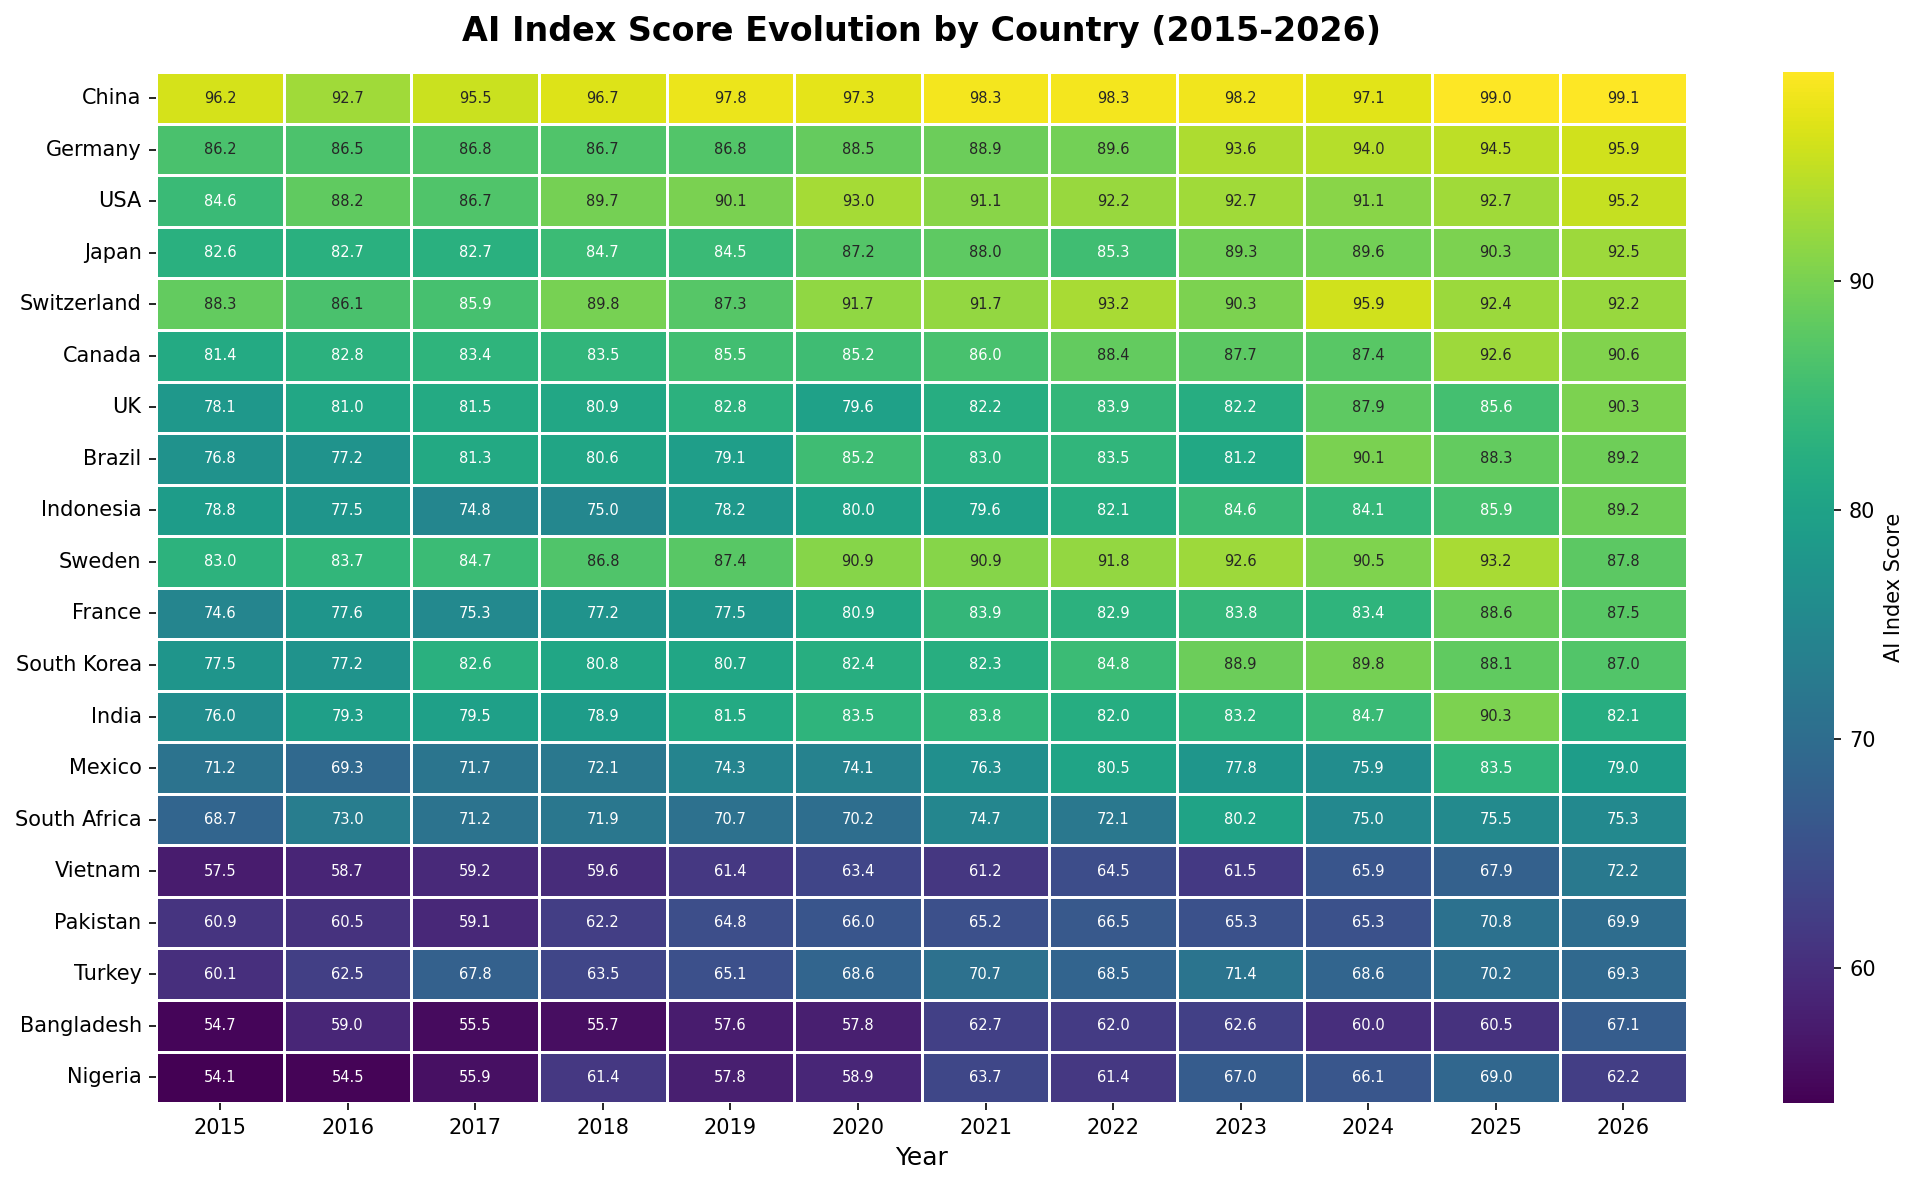

In [9]:
# Pivot for heatmap: countries sorted by 2026 score
rank_order = df_2026.sort_values('ai_index_score', ascending=False)['country'].tolist()
pivot = df.pivot_table(index='country', columns='year', values='ai_index_score')
pivot = pivot.loc[rank_order]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='viridis', linewidths=0.5,
            cbar_kws={'label': 'AI Index Score'}, ax=ax, annot_kws={'size': 7})
ax.set_title('AI Index Score Evolution by Country (2015-2026)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('exports/02_heatmap_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.3 Radar Chart — Top 5 Countries Across Key Dimensions (2026)

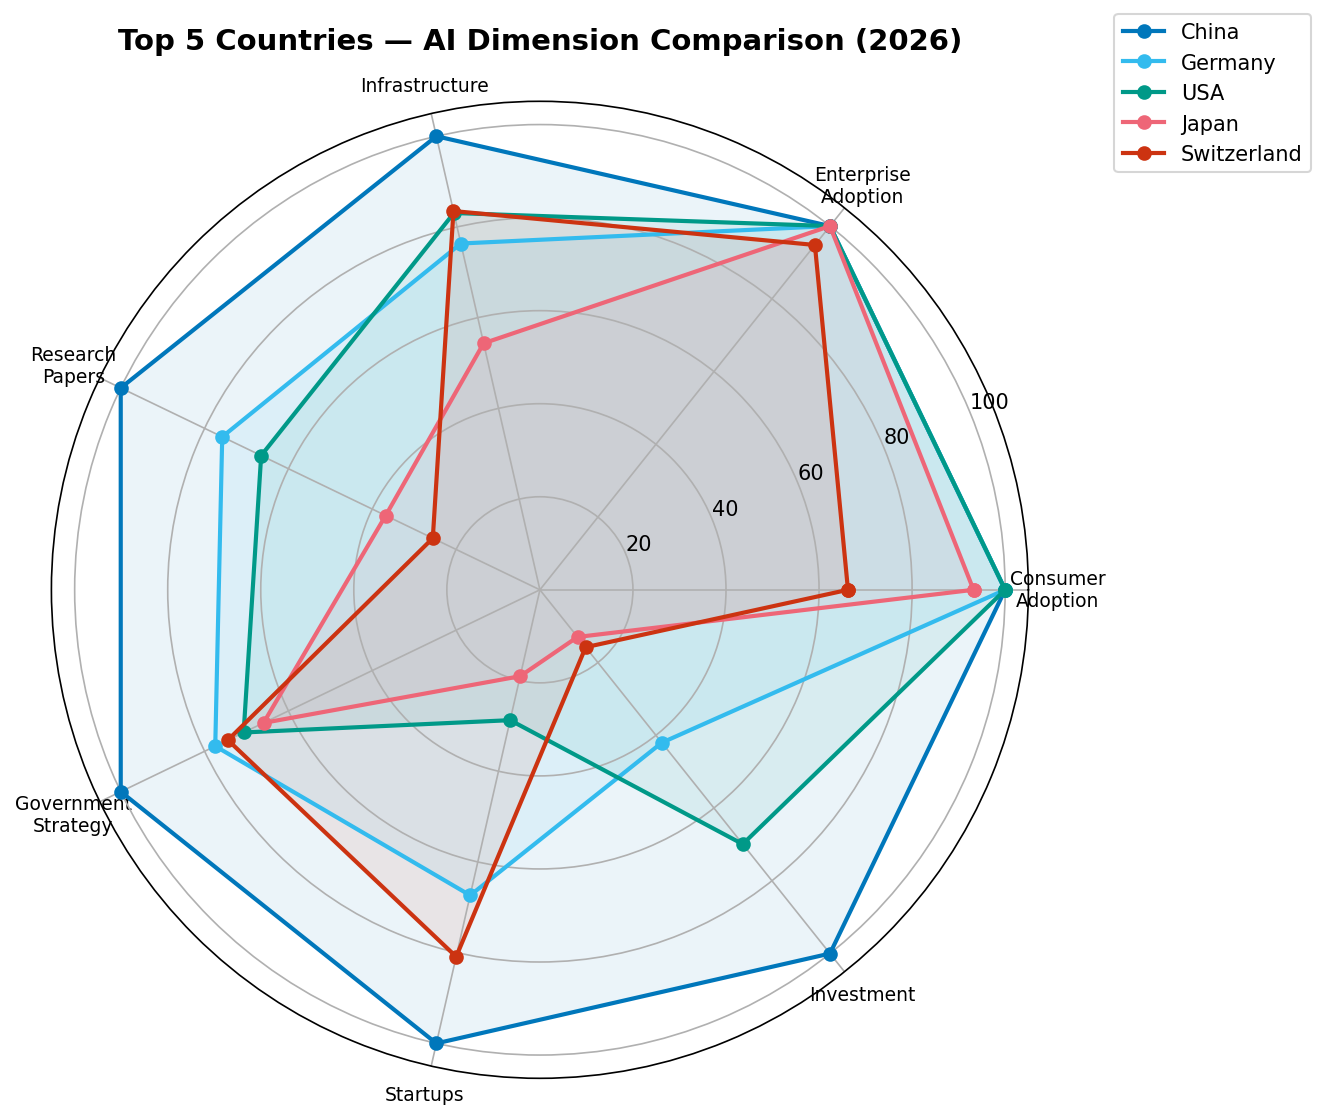

In [10]:
# Define key dimension columns
dimensions = {
    'Consumer\nAdoption': 'ai_adoption_consumer',
    'Enterprise\nAdoption': 'ai_adoption_enterprise',
    'Infrastructure': 'cloud_infrastructure',
    'Research\nPapers': 'ai_research_papers',
    'Government\nStrategy': 'ai_policy_score',
    'Startups': 'ai_startups_count',
    'Investment': 'ai_investment_billion_usd'
}

# Get top 5 countries by 2026 AI Index Score
top5 = df_2026.nlargest(5, 'ai_index_score')['country'].tolist()

# Normalize each dimension to 0-100 scale for fair comparison
df_radar = df_2026[df_2026['country'].isin(top5)].copy()
for label, col in dimensions.items():
    col_min = df_2026[col].min()
    col_max = df_2026[col].max()
    df_radar[col + '_norm'] = (df_radar[col] - col_min) / (col_max - col_min) * 100

# Plot radar
categories = list(dimensions.keys())
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = CB_PALETTE[:5]

for i, country in enumerate(top5):
    row = df_radar[df_radar['country'] == country]
    values = [row[col + '_norm'].values[0] for col in dimensions.values()]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=country, color=colors[i])
    ax.fill(angles, values, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 105)
ax.set_title('Top 5 Countries — AI Dimension Comparison (2026)', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('exports/03_radar_top5.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.4 Grouped Bar Chart — Top 10 Countries by Pillar Scores (2026)

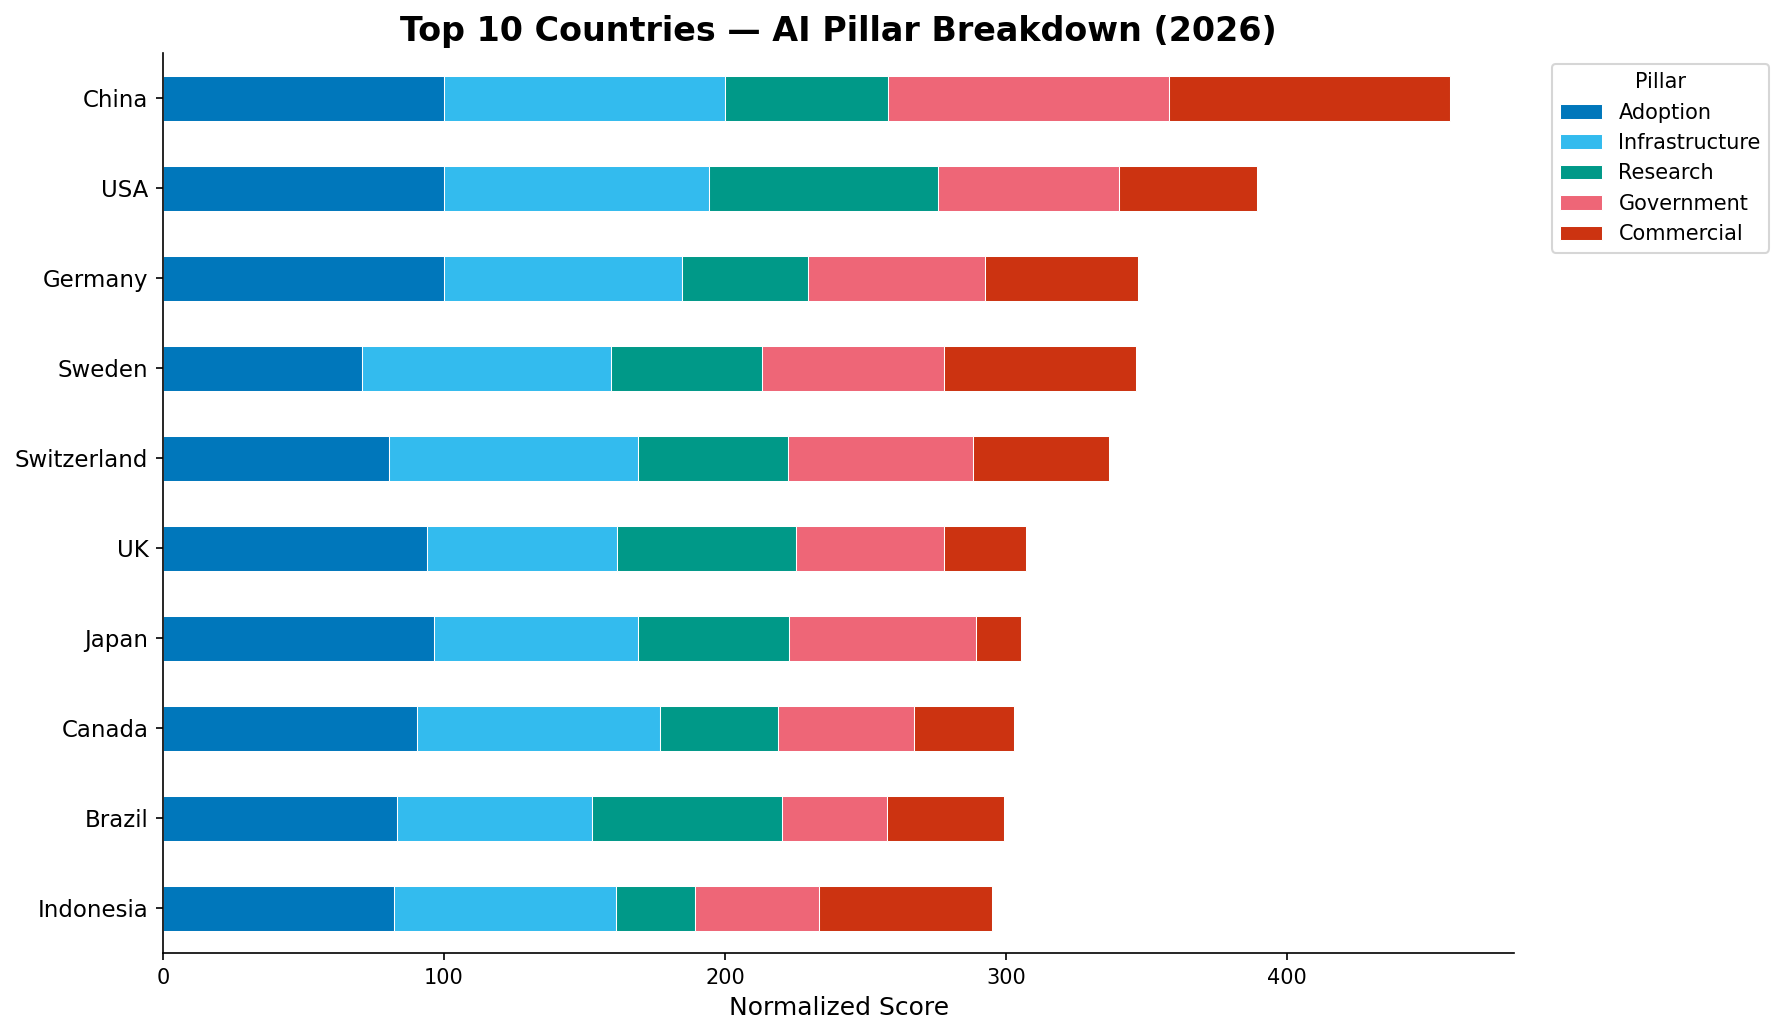

In [11]:
# Define pillar groupings (averaged)
pillars = {
    'Adoption': ['ai_adoption_consumer', 'ai_adoption_enterprise'],
    'Infrastructure': ['cloud_infrastructure', 'internet_penetration', '5g_coverage_pct'],
    'Research': ['ai_research_papers', 'rd_spending_gdp_pct'],
    'Government': ['ai_policy_score', 'ai_regulation_score', 'government_ai_spending'],
    'Commercial': ['ai_startups_count', 'ai_investment_billion_usd']
}

top10 = df_2026.nlargest(10, 'ai_index_score')['country'].tolist()
df_bar = df_2026[df_2026['country'].isin(top10)].set_index('country')

# Normalize and average pillars
pillar_scores = pd.DataFrame(index=top10)
for pillar_name, cols in pillars.items():
    for col in cols:
        col_min = df_2026[col].min()
        col_max = df_2026[col].max()
        df_bar[col + '_n'] = (df_bar[col] - col_min) / (col_max - col_min) * 100
    pillar_scores[pillar_name] = df_bar[[c + '_n' for c in cols]].mean(axis=1).loc[top10]

# Sort by total
pillar_scores = pillar_scores.loc[pillar_scores.sum(axis=1).sort_values(ascending=True).index]

# Horizontal stacked bar
fig, ax = plt.subplots(figsize=(12, 7))
pillar_scores.plot(kind='barh', stacked=True, ax=ax, color=CB_PALETTE[:5], edgecolor='white', linewidth=0.5)
ax.set_title('Top 10 Countries — AI Pillar Breakdown (2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Normalized Score', fontsize=12)
ax.set_ylabel('')
ax.legend(title='Pillar', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig('exports/04_bar_top10.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.5 Correlation Matrix

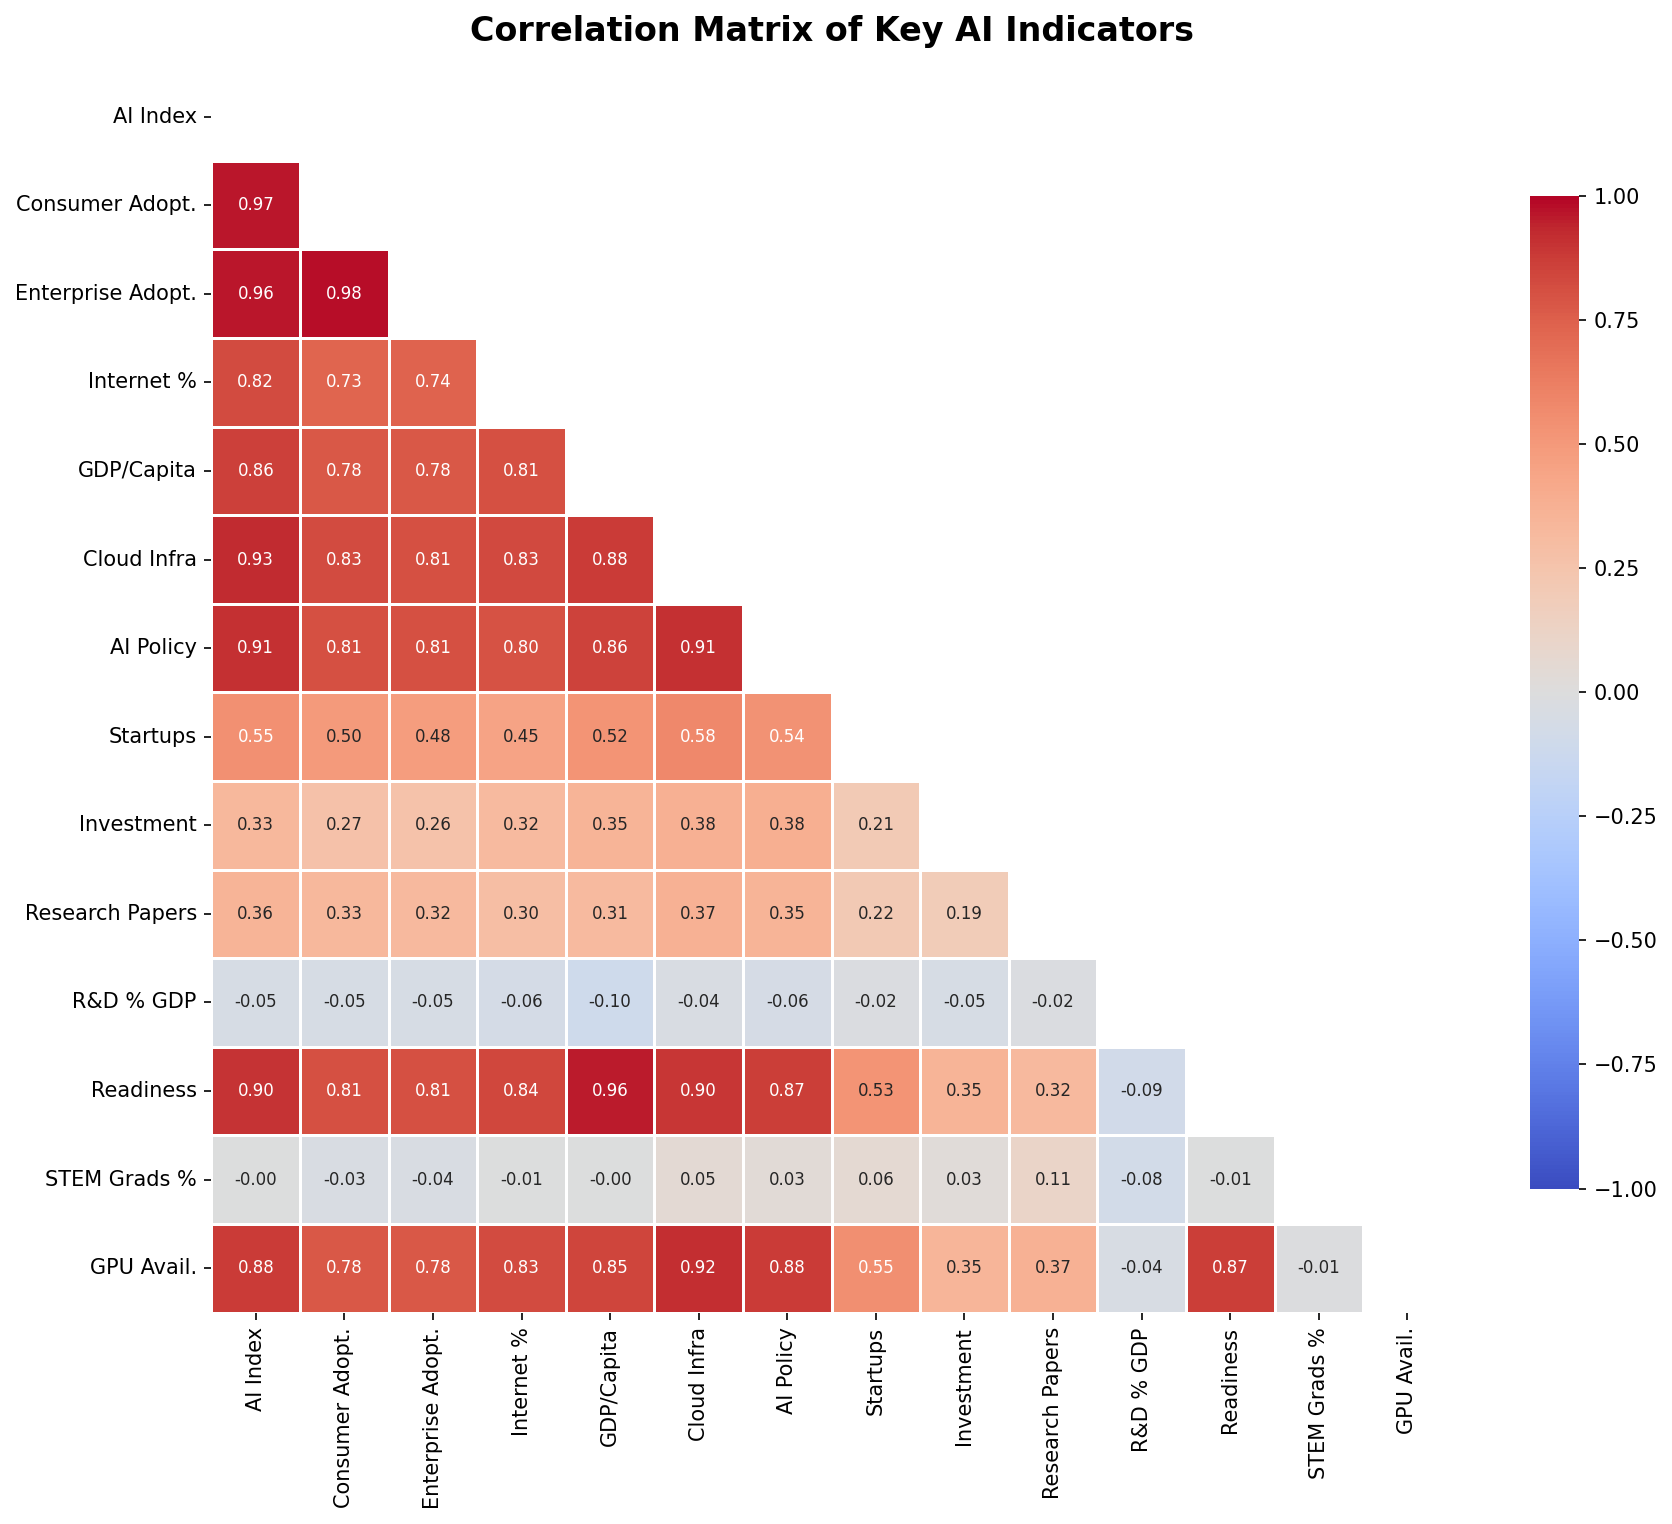

In [12]:
corr_cols = ['ai_index_score', 'ai_adoption_consumer', 'ai_adoption_enterprise',
             'internet_penetration', 'gdp_per_capita', 'cloud_infrastructure',
             'ai_policy_score', 'ai_startups_count', 'ai_investment_billion_usd',
             'ai_research_papers', 'rd_spending_gdp_pct', 'ai_readiness_score',
             'stem_graduates_pct', 'gpu_availability_index']

# Shorten labels for readability
label_map = {
    'ai_index_score': 'AI Index',
    'ai_adoption_consumer': 'Consumer Adopt.',
    'ai_adoption_enterprise': 'Enterprise Adopt.',
    'internet_penetration': 'Internet %',
    'gdp_per_capita': 'GDP/Capita',
    'cloud_infrastructure': 'Cloud Infra',
    'ai_policy_score': 'AI Policy',
    'ai_startups_count': 'Startups',
    'ai_investment_billion_usd': 'Investment',
    'ai_research_papers': 'Research Papers',
    'rd_spending_gdp_pct': 'R&D % GDP',
    'ai_readiness_score': 'Readiness',
    'stem_graduates_pct': 'STEM Grads %',
    'gpu_availability_index': 'GPU Avail.'
}

corr = df[corr_cols].corr()
corr.index = [label_map[c] for c in corr.index]
corr.columns = [label_map[c] for c in corr.columns]

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8},
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Key AI Indicators', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('exports/05_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 4. Interactive Visualizations (Plotly)

### 4.1 Animated Scatter — GDP vs AI Index Score Over Time

In [13]:
fig = px.scatter(
    df.sort_values('year'),
    x='gdp_per_capita',
    y='ai_index_score',
    size='ai_investment_billion_usd',
    color='region',
    hover_name='country',
    animation_frame='year',
    animation_group='country',
    size_max=45,
    range_x=[df['gdp_per_capita'].min() - 5000, df['gdp_per_capita'].max() + 5000],
    range_y=[df['ai_index_score'].min() - 5, df['ai_index_score'].max() + 5],
    title='GDP per Capita vs AI Index Score (2015-2026)',
    labels={
        'gdp_per_capita': 'GDP per Capita (USD)',
        'ai_index_score': 'AI Index Score',
        'ai_investment_billion_usd': 'AI Investment ($B)',
        'region': 'Region'
    },
    color_discrete_sequence=CB_PALETTE
)
fig.update_layout(
    title_font_size=18, title_x=0.5,
    width=950, height=600,
    plot_bgcolor='white',
    xaxis=dict(gridcolor='#f0f0f0', zeroline=False),
    yaxis=dict(gridcolor='#f0f0f0', zeroline=False)
)
fig.write_html('exports/06_animated_scatter.html')
fig.show()

### 4.2 Interactive Line Chart — AI Index Trends

In [14]:
fig = px.line(
    df.sort_values(['country', 'year']),
    x='year',
    y='ai_index_score',
    color='country',
    hover_data={'ai_global_rank': True, 'region': True},
    title='AI Index Score Trends by Country (2015-2026)',
    labels={'ai_index_score': 'AI Index Score', 'year': 'Year', 'country': 'Country'},
    color_discrete_sequence=px.colors.qualitative.Set2 + px.colors.qualitative.Set3
)
fig.update_layout(
    title_font_size=18, title_x=0.5,
    width=1000, height=600,
    plot_bgcolor='white',
    xaxis=dict(gridcolor='#f0f0f0', dtick=1),
    yaxis=dict(gridcolor='#f0f0f0'),
    hovermode='x unified'
)
fig.update_traces(line_width=2)
fig.write_html('exports/07_interactive_trends.html')
fig.show()

### 4.3 Sunburst Chart — Region > Country > AI Score (2026)

In [15]:
fig = px.sunburst(
    df_2026,
    path=['region', 'country'],
    values='ai_index_score',
    color='ai_index_score',
    color_continuous_scale='Viridis',
    title='AI Index Score Distribution by Region & Country (2026)',
    hover_data={'ai_global_rank': True}
)
fig.update_layout(
    title_font_size=18, title_x=0.5,
    width=800, height=700,
    margin=dict(t=60, b=10, l=10, r=10)
)
fig.write_html('exports/08_sunburst.html')
fig.show()

---
## 5. Key Insights & Storytelling

### The Global AI Race: Who's Leading and Why?

**Key Findings:**

In [16]:
# Generate key insights programmatically
print('=' * 60)
print('KEY INSIGHTS FROM THE GLOBAL AI INDEX (2015-2026)')
print('=' * 60)

# 1. Top countries in 2026
top5_2026 = df_2026.nlargest(5, 'ai_index_score')[['country', 'ai_index_score', 'ai_global_rank']]
print('\n1. TOP 5 COUNTRIES BY AI INDEX SCORE (2026):')
for _, row in top5_2026.iterrows():
    print(f'   {row["country"]}: {row["ai_index_score"]:.1f} (Rank #{int(row["ai_global_rank"])})')

# 2. Biggest risers (2015 to 2026)
df_2015 = df[df['year'] == 2015].set_index('country')['ai_index_score']
df_2026_s = df_2026.set_index('country')['ai_index_score']
growth = ((df_2026_s - df_2015) / df_2015 * 100).sort_values(ascending=False)
print('\n2. BIGGEST IMPROVERS (2015 -> 2026):')
for country in growth.head(5).index:
    print(f'   {country}: +{growth[country]:.1f}% growth')

# 3. Regional averages
region_avg = df_2026.groupby('region')['ai_index_score'].mean().sort_values(ascending=False)
print('\n3. REGIONAL AVERAGES (2026):')
for region, score in region_avg.items():
    print(f'   {region}: {score:.1f}')

# 4. Investment leaders
invest = df_2026.nlargest(3, 'ai_investment_billion_usd')[['country', 'ai_investment_billion_usd']]
print('\n4. TOP AI INVESTORS (2026):')
for _, row in invest.iterrows():
    print(f'   {country}: ${row["ai_investment_billion_usd"]:.1f}B')

print('\n' + '=' * 60)

KEY INSIGHTS FROM THE GLOBAL AI INDEX (2015-2026)

1. TOP 5 COUNTRIES BY AI INDEX SCORE (2026):
   China: 99.1 (Rank #1)
   Germany: 95.9 (Rank #2)
   USA: 95.2 (Rank #3)
   Japan: 92.5 (Rank #4)
   Switzerland: 92.2 (Rank #5)

2. BIGGEST IMPROVERS (2015 -> 2026):
   Vietnam: +25.6% growth
   Bangladesh: +22.6% growth
   France: +17.2% growth
   Brazil: +16.1% growth
   UK: +15.5% growth

3. REGIONAL AVERAGES (2026):
   South America: 89.2
   North America: 88.2
   Europe: 87.2
   Asia: 82.4
   Africa: 68.7

4. TOP AI INVESTORS (2026):
   UK: $195.0B
   UK: $192.1B
   UK: $165.8B

